In [57]:
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import umap
import torch
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

from mmidas.utils.config_tools import get_paths
from mmidas.utils.batch_removal import align_query

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
toml_file = 'pyproject.toml'
config = get_paths(toml_file=toml_file)
data_file_1 = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['anndata_file_1']
data_file_2 = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['anndata_file_2']
data_file_3 = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['anndata_file_3']
print(data_file_1)
print(data_file_2)
print(data_file_3)

/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/pyproject.toml
Getting files directories belong to data...
Getting files directories belong to models...
/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/data/Dbh_cluster.h5ad
/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/data/multiome_LC-NE_Dbh_cluster.h5ad
/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/data/retroSeq.h5ad


In [11]:
n_genes = 5000
hvgs_datasets = []
for file in [data_file_1, data_file_2, data_file_3]:
    hvgs_batch = []
    adata = sc.read_h5ad(file)
    scale_factor = 1e6
    logcpm = adata.X.toarray()
    genes = adata.var.index.values
    print(f'All cells are normalized - {any(np.sum(np.exp(logcpm) - 1, axis=1) == scale_factor)}')
    print(adata.obs.keys())
    if 'batch' in adata.obs.keys():
        batch = adata.obs['batch']
        hvgs_batch = []
        
        for b in batch.unique():
            genes_std_ = np.std(logcpm[batch==b, :], axis=0)
            hvgs_indx_ = np.argsort(genes_std_)[::-1][:n_genes]
            hvgs_batch.append(genes[hvgs_indx_])
            
        hvgs_datasets.append(np.unique(hvgs_batch))
    else:
        genes_std_ = np.std(logcpm, axis=0)
        hvgs_indx_ = np.argsort(genes_std_)[::-1][:n_genes]
        hvgs_datasets.append(genes[hvgs_indx_])
    
hvgs = list(set(hvgs_datasets[0]).intersection(*hvgs_datasets[1:]))
print(f'Number of HVGs: {len(hvgs)}')

All cells are normalized - True
Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample_id', 'umi.counts',
       'batch', 'external_donor_name', 'sex', 'roi', 'rna_amplification_set',
       'library_prep_set', 'exclude', 'exclude2', 'load_name', 'doublet_score',
       'experiment', 'platform', 'percent.mt', 'percent.rb', 'cell_class'],
      dtype='object')
All cells are normalized - True
Index(['cell_ids'], dtype='object')
All cells are normalized - True
Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'facs_container',
       'sample_name', 'exp_component_name', 'age', 'gender', 'cre_line',
       'reporter', 'injection_target', 'seq_run', 'external_donor_name',
       'experiment', 'platform', 'percent.mt', 'percent.rb', 'RNA_snn_res.0.1',
       'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4',
       'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7',
       'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1',
       'seurat_clusters'],
      dtype='object')


Minimum std: 1.31484394340706, Maximum std: 3.318265499277989, num of cells: 4608
Minimum std: 1.976581990578413, Maximum std: 3.3436737462471378, num of cells: 3715
Minimum std: 1.9641035570145644, Maximum std: 2.8793581141876308, num of cells: 525


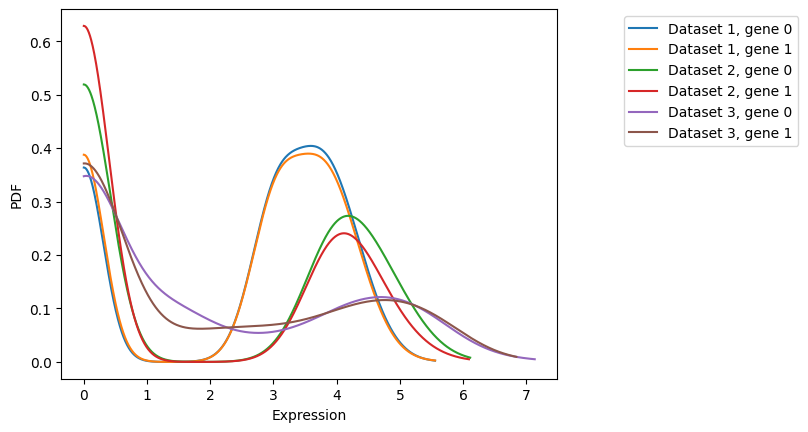

In [75]:
plt.Figure()
for i_f, file in enumerate([data_file_1, data_file_2, data_file_3]):
    adata = sc.read_h5ad(file)
    genes = adata.var.index.values
    g_index = [np.where(genes == g)[0][0] for g in hvgs]
    X = adata.X[:, g_index].toarray()
    g_std = np.std(X, axis=0)
    print(f'Minimum std: {np.min(g_std)}, Maximum std: {np.max(g_std)}, num of cells: {X.shape[0]}')
    for ii in range(2):
        kde = gaussian_kde(X[:, ii])
        x = np.linspace(min(X[:, ii]), max(X[:, ii]), 1000)  # Generate points for x-axis
        pdf = kde(x) 
        plt.plot(x, pdf, label=f'Dataset {i_f+1}, gene {ii}')

plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.ylabel('PDF')
plt.xlabel('Expression')
plt.show()
hvgs_df_1 = pd.DataFrame({'gene': hvgs})
# hvgs_df_1.to_csv(config['paths']['main_dir'] / config['paths']['data_path'] / 'hvg_perdataset.csv', index=False)

In [50]:
genes = []
X = []
for i_f, file in enumerate([data_file_1, data_file_2, data_file_3]):
    adata = sc.read_h5ad(file)
    genes.append(adata.var.index.values)

all_genes = np.array(list(set(genes[0]).intersection(*genes[1:])))
for i_f, file in enumerate([data_file_1, data_file_2, data_file_3]):
    adata = sc.read_h5ad(file)
    genes = adata.var.index.values
    g_index = [np.where(genes == g)[0][0] for g in all_genes]
    X.append(adata.X[:, g_index].toarray())
    
X = np.vstack(X)
g_std = np.std(X, axis=0)
hvgs_indx = np.argsort(g_std)[::-1][:2000]
hvgs_2 = all_genes[hvgs_indx]

Minimum std: 0.3900213944368793, Maximum std: 3.318265499277989, num of cells: 4608
Minimum std: 1.3903367111562717, Maximum std: 3.3436737462471378, num of cells: 3715
Minimum std: 0.15074957753344626, Maximum std: 2.8793581141876308, num of cells: 525


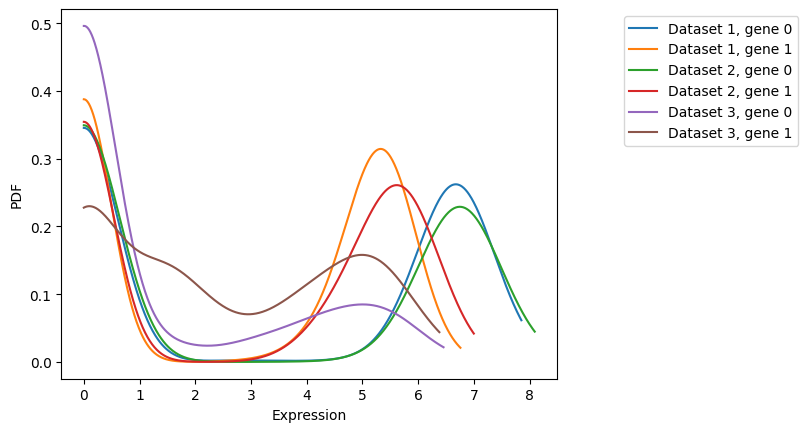

In [74]:
plt.Figure()
for i_f, file in enumerate([data_file_1, data_file_2, data_file_3]):
    adata = sc.read_h5ad(file)
    genes = adata.var.index.values
    g_index = [np.where(genes == g)[0][0] for g in hvgs_2]
    X = adata.X[:, g_index].toarray()
    g_std = np.std(X, axis=0)
    print(f'Minimum std: {np.min(g_std)}, Maximum std: {np.max(g_std)}, num of cells: {X.shape[0]}')
    for ii in range(2):
        kde = gaussian_kde(X[:, ii])
        x = np.linspace(min(X[:, ii]), max(X[:, ii]), 1000)  # Generate points for x-axis
        pdf = kde(x) 
        plt.plot(x, pdf, label=f'Dataset {i_f+1}, gene {ii}')

plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.ylabel('PDF')
plt.xlabel('Expression')
plt.show()
hvgs_df_2 = pd.DataFrame({'gene': hvgs_2})

In [55]:
hvgs_df_2.to_csv(config['paths']['main_dir'] / config['paths']['data_path'] / 'hvg_perdataset.csv', index=False)

In [58]:
ref_data = []
for i_f, file in enumerate([data_file_1, data_file_2]):
    adata = sc.read_h5ad(file)
    genes = adata.var.index.values
    g_index = [np.where(genes == g)[0][0] for g in hvgs_2]
    ref_data.append(adata.X[:, g_index].toarray())

ref_data = np.vstack(ref_data)

andata = sc.read_h5ad(data_file_3)
g_index = [np.where(andata.var.index.values == g)[0][0] for g in hvgs_2]
query_data = andata.X[:, g_index].toarray()


In [ ]:
# convert data to torch
ref_data = torch.tensor(ref_data, dtype=torch.float32)
query_data = torch.tensor(query_data, dtype=torch.float32)
# Remove batch effect between AD and patchseq data
corrected_mtx = align_query(reference=ref_data, query=query_data, neighborhood_size=250, num_anchors=5, kernel_scale=5.0)
print(np.isnan(corrected_mtx).sum())

/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/Temp/ipykernel_142196/3951734106.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ref_data = torch.tensor(ref_data, dtype=torch.float32)
/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/Temp/ipykernel_142196/3951734106.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  query_data = torch.tensor(query_data, dtype=torch.float32)


Determining neighborhood...
Computing correction...      
Completed.                           


In [69]:
# Evaluate the alignment between AD and patchseq data
corrected_data = corrected_mtx.detach().numpy()
dataset_1 = np.concatenate((ref_data.numpy(), query_data.numpy()), axis=0)
dataset_2 = np.concatenate((ref_data.numpy(), corrected_data), axis=0)
embedding_1 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_1)
embedding_2 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_2)

/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


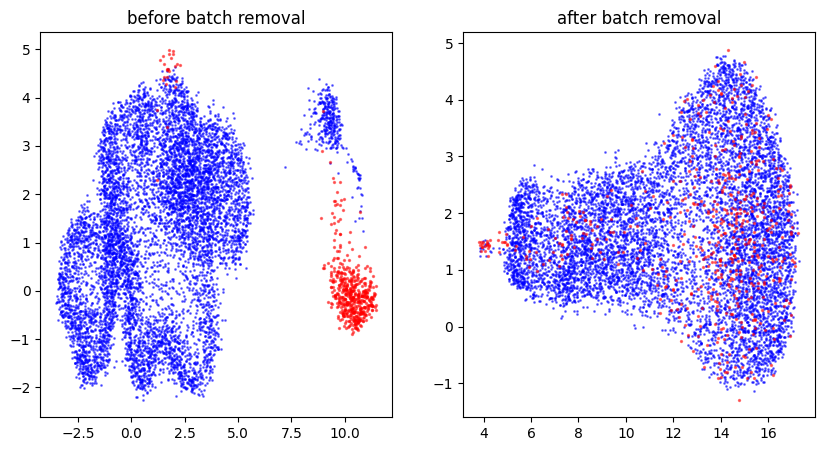

In [70]:
ref_samp_size = ref_data.shape[0]   
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(embedding_1[:ref_samp_size, 0], embedding_1[:ref_samp_size, 1], s=1, color='blue', alpha=0.5)
ax[0].scatter(embedding_1[ref_samp_size:, 0], embedding_1[ref_samp_size:, 1], s=2, color='red', alpha=.5)
ax[1].scatter(embedding_2[:ref_samp_size, 0], embedding_2[:ref_samp_size, 1], s=1, color='blue', alpha=0.5)
ax[1].scatter(embedding_2[ref_samp_size:, 0], embedding_2[ref_samp_size:, 1], s=2, color='red', alpha=.5)
ax[0].set_title('before batch removal')
ax[1].set_title('after batch removal')
plt.show()

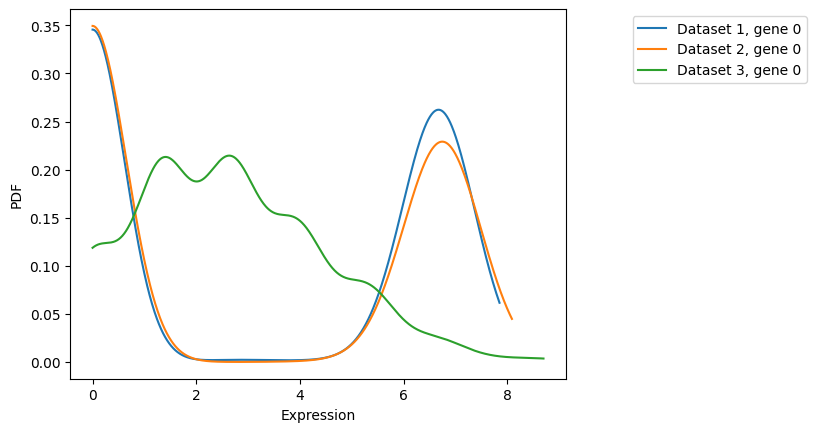

In [73]:
plt.Figure()
for i_f, file in enumerate([data_file_1, data_file_2, data_file_3]):
    if i_f < 2:
        adata = sc.read_h5ad(file)
        genes = adata.var.index.values
        g_index = [np.where(genes == g)[0][0] for g in hvgs_2]
        X = adata.X[:, g_index].toarray()
    else:
        X = corrected_data.copy()
    
    for ii in range(1):
        kde = gaussian_kde(X[:, ii])
        x = np.linspace(min(X[:, ii]), max(X[:, ii]), 1000)  # Generate points for x-axis
        pdf = kde(x) 
        plt.plot(x, pdf, label=f'Dataset {i_f+1}, gene {ii}')

plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.ylabel('PDF')
plt.xlabel('Expression')
plt.show()